# Model 1 — Black-76 Delta-Neutral Hedge Backtest

**Position:** Short 1 × TXO20000P5 (April 2025 PUT, K=20,000, expiry 2025-04-16)  
**Hedge:** TX April-2025 futures (fractional lots OK)  
**Window:** 2025-03-19 → 2025-04-16 (19 trading days)  
**Execution:** TAIFEX daily settlement prices only — no intraday fills  
**Pricing model:** Black's 1976 formula (futures-as-forward; no cost-of-carry)

---

## Notebook Structure
1. Imports & constants
2. Load & validate data
3. Black-76 formula walkthrough (single day)
4. Full backtest loop (Steps 1–10 from CLAUDE.md)
5. Per-day results table
6. Cumulative P&L
7. IV and delta evolution
8. P&L attribution
9. Summary & key takeaways

## 1. Imports & Constants

In [1]:
import sys
import math
import warnings
from pathlib import Path
from dataclasses import asdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy.stats import norm

# Add project root to path so we can import models/ and backtest/
ROOT = Path().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from models.black_scholes import bs_put_price, bs_put_greeks, implied_vol
from backtest.costs import tx_transaction_cost, txo_inception_cost
from backtest.pnl import DailyPnL, compute_daily_pnl, compute_expiry_pnl

RAW = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"

# ── Contract parameters ─────────────────────────────────────────────────────
STRIKE        = 20_000.0
EXPIRY        = pd.Timestamp("2025-04-16")
OPT_MULT      = 50       # NT$ per index point, TXO
FUT_MULT      = 200      # NT$ per index point, TX
HEDGE_RATIO   = OPT_MULT / FUT_MULT   # 0.25
FINAL_SETTLE  = 19_468.0  # TAIEX close 2025-04-16 (best approximation)

print(f"HEDGE_RATIO = {OPT_MULT}/{FUT_MULT} = {HEDGE_RATIO}")
print(f"Final settlement (approx): {FINAL_SETTLE:,.0f}")
print(f"Intrinsic at expiry: max(0, {STRIKE:,.0f} - {FINAL_SETTLE:,.0f}) = {max(0, STRIKE-FINAL_SETTLE):,.0f} pts = NT${max(0,STRIKE-FINAL_SETTLE)*OPT_MULT:,.0f}")

HEDGE_RATIO = 50/200 = 0.25
Final settlement (approx): 19,468
Intrinsic at expiry: max(0, 20,000 - 19,468) = 532 pts = NT$26,600


## 2. Load & Validate Data

In [2]:
# ── TX April-2025 futures ────────────────────────────────────────────────────
tx_raw = pd.read_csv(RAW / "TX_20250319-20250416.csv", dtype=str, index_col=False)
tx_raw.columns = tx_raw.columns.str.strip()
tx = tx_raw[
    (tx_raw["contract month(Week)"].str.strip() == "202504") &
    (tx_raw["Trading Session"].str.strip() == "Regular")
].copy()
tx["date"] = pd.to_datetime(tx["date"].str.strip(), format="%Y/%m/%d")
tx["F"] = pd.to_numeric(tx["settlement_price"], errors="coerce")
# Expiry-day TAIFEX convention: publish 0; substitute TAIEX close
tx.loc[(tx["date"] == EXPIRY) & (tx["F"] == 0), "F"] = FINAL_SETTLE
tx = tx[["date", "F"]].set_index("date").sort_index()

# ── TXO20000P monthly April-2025 ─────────────────────────────────────────────
txo_raw = pd.read_csv(RAW / "TXO_20250319-20250416.csv", dtype=str, index_col=False)
txo_raw.columns = txo_raw.columns.str.strip()
txo = txo_raw[
    (txo_raw["Contract Month(Week)"].str.strip() == "202504") &
    (txo_raw["Strike Price"].str.strip() == "20000.0000") &
    (txo_raw["Call/Put"].str.strip() == "Put") &
    (txo_raw["Trading Session"].str.strip() == "Regular")
].copy()
txo["date"] = pd.to_datetime(txo["Date"].str.strip(), format="%Y/%m/%d")
txo["P"] = pd.to_numeric(txo["Settlement Price"], errors="coerce")
# Expiry day: settlement = 0 by convention; use intrinsic
txo.loc[txo["date"] == EXPIRY, "P"] = max(0.0, STRIKE - FINAL_SETTLE)
txo = txo[["date", "P"]].set_index("date").sort_index()

# ── TAIEX spot ───────────────────────────────────────────────────────────────
spot_raw = pd.read_csv(RAW / "^twse_d.csv")
spot = spot_raw.copy()
spot["date"] = pd.to_datetime(spot["Date"].str.strip(), format="%Y-%m-%d")
spot = spot[["date", "Close"]].rename(columns={"Close": "S"}).set_index("date").sort_index()

# ── CBC 31-90 Day CP rate ─────────────────────────────────────────────────────
cbc_raw = pd.read_csv(RAW / "CBC_Interest_Rates.csv", skiprows=3, header=0)
cbc_raw.columns = cbc_raw.columns.str.strip()
cbc = cbc_raw.iloc[:, [0, 7]].copy()
cbc.columns = ["month_str", "cp_rate_str"]
cbc = cbc[cbc["month_str"].str.match(r"^\d{4}\.\d{2}$", na=False)].copy()
cbc["date"] = pd.to_datetime(cbc["month_str"].str.replace(".", "-", regex=False) + "-01")
cbc["r"] = pd.to_numeric(cbc["cp_rate_str"].str.strip(), errors="coerce") / 100.0
cbc = cbc[["date", "r"]].dropna().set_index("date").sort_index()
# Linear interpolation to daily
daily_idx = pd.date_range(cbc.index.min(), cbc.index.max(), freq="D")
rates = cbc.reindex(daily_idx).interpolate(method="time")

# ── Merge onto backtest trading days ─────────────────────────────────────────
master = tx.join(spot, how="left").join(txo, how="left").join(rates, how="left")
# (EXPIRY - index).days returns a plain Index in newer pandas; wrap as Series before clip
t_days = pd.Series((EXPIRY - master.index).days, index=master.index)
master["T"] = (t_days / 365.0).clip(lower=0.0)

print(f"Trading days loaded: {len(master)}")
print()
master

Trading days loaded: 19



,F,S,P,r,T
date,,,,,
2025-03-19,22018,21960.83,68.0,0.015826,0.076712
2025-03-20,22365,22377.26,32.5,0.015816,0.073973
2025-03-21,22181,22209.10,40.0,0.015806,0.071233
2025-03-24,22151,22106.64,40.0,0.015777,0.063014
2025-03-25,22301,22273.19,26.5,0.015768,0.060274
2025-03-26,22304,22260.29,21.5,0.015758,0.057534
2025-03-27,21971,21951.76,35.0,0.015748,0.054795
2025-03-28,21599,21602.89,63.0,0.015739,0.052055
2025-03-31,20764,20695.90,247.0,0.015710,0.043836


In [3]:
# Validation checks
assert master.index[0]  == pd.Timestamp("2025-03-19"), "First day mismatch"
assert master.index[-1] == pd.Timestamp("2025-04-16"), "Last day mismatch"
assert master["F"].notna().all(),  "Missing TX futures settlement"
assert master["P"].notna().all(),  "Missing TXO put settlement"
assert abs(float(master.loc["2025-03-19", "F"]) - 22018) < 1, "Day-0 TX settlement mismatch"

print("All validation checks passed.")
print(f"Day-0  TX futures settlement : {master.loc['2025-03-19','F']:,.0f}  (expected 22,018)")
print(f"Day-0  TXO20000P settlement  : {master.loc['2025-03-19','P']:,.1f}  pts = NT${master.loc['2025-03-19','P']*OPT_MULT:,.0f}")
print(f"Day-0  CBC CP rate (annl.)   : {master.loc['2025-03-19','r']*100:.4f}%")
print(f"Day-18 TAIEX close (expiry)  : {master.loc['2025-04-16','S']:,.2f}")

All validation checks passed.
Day-0  TX futures settlement : 22,018  (expected 22,018)
Day-0  TXO20000P settlement  : 68.0  pts = NT$3,400
Day-0  CBC CP rate (annl.)   : 1.5826%
Day-18 TAIEX close (expiry)  : 19,468.00


## 3. Black-76 Formula Walkthrough (Day 0)

Since TXO and TX share the same expiry, the TX futures price **is** the cost-of-carry-adjusted forward — no dividend or carry adjustment needed.

$$
d_1 = \frac{\ln(F/K) + \frac{1}{2}\sigma^2 T}{\sigma\sqrt{T}}, \quad
d_2 = d_1 - \sigma\sqrt{T}
$$
$$
P_{\text{put}} = e^{-rT}\bigl[K\,N(-d_2) - F\,N(-d_1)\bigr]
$$
$$
\Delta_{\text{put}} = -e^{-rT}\,N(-d_1) \quad (\text{w.r.t. }F)
$$

**Hedge conversion** (short put → positive delta → sell futures):  
$$
h_t = -|\Delta_{\text{put}}| \times \underbrace{\frac{50}{200}}_{0.25} \quad \text{TX contracts (negative = short)}
$$

In [4]:
# ── Day 0: step through the formula manually ──────────────────────────────────
row0 = master.iloc[0]
F0, K, r0, T0, P_mkt = float(row0["F"]), STRIKE, float(row0["r"]), float(row0["T"]), float(row0["P"])

print("=== Day 0: 2025-03-19 ===")
print(f"  F (TX Apr futures)  = {F0:,.1f}")
print(f"  K (strike)          = {K:,.0f}")
print(f"  r (CBC CP rate)     = {r0*100:.4f}%")
print(f"  T (years to expiry) = {T0:.4f}  ({T0*365:.0f} calendar days)")
print(f"  P_market            = {P_mkt:.2f} pts = NT${P_mkt*OPT_MULT:,.0f}")
print()

iv0 = implied_vol(F0, K, r0, T0, P_mkt)
g0  = bs_put_greeks(F0, K, r0, T0, iv0)

sqrtT = math.sqrt(T0)
d1 = (math.log(F0/K) + 0.5*iv0**2*T0) / (iv0*sqrtT)
d2 = d1 - iv0*sqrtT

print(f"  Implied vol (IV)    = {iv0*100:.4f}%")
print(f"  d1 = {d1:.6f}")
print(f"  d2 = {d2:.6f}")
print(f"  N(-d1) = {norm.cdf(-d1):.6f}")
print(f"  N(-d2) = {norm.cdf(-d2):.6f}")
print()
print(f"  BS price (check)    = {g0['price']:.4f} pts  (market = {P_mkt:.2f})")
print()
print("  Greeks (long put basis):")
print(f"    Δ (w.r.t. F)      = {g0['delta']:.6f}")
print(f"    Γ                 = {g0['gamma']:.8f} per index pt²")
print(f"    Vega              = {g0['vega']:.4f} per unit vol")
print(f"    Θ (per day)       = {g0['theta']:.4f} pts/day")
print()

short_put_delta = -g0["delta"]   # positive
h0 = -short_put_delta * HEDGE_RATIO
print(f"  Short-put portfolio delta  = +{short_put_delta:.6f}  (long put delta × -1)")
print(f"  TX contracts to SHORT      = {short_put_delta:.6f} × 0.25 = {h0:.6f}  (h₀ = {h0:.6f})")
print(f"  Notional hedged            = {abs(h0)*FUT_MULT*F0:,.0f} NT$ equivalent")

=== Day 0: 2025-03-19 ===
  F (TX Apr futures)  = 22,018.0
  K (strike)          = 20,000
  r (CBC CP rate)     = 1.5826%
  T (years to expiry) = 0.0767  (28 calendar days)
  P_market            = 68.00 pts = NT$3,400

  Implied vol (IV)    = 26.4414%
  d1 = 1.349220
  d2 = 1.275986
  N(-d1) = 0.088633
  N(-d2) = 0.100980

  BS price (check)    = 67.9995 pts  (market = 68.00)

  Greeks (long put basis):
    Δ (w.r.t. F)      = -0.088526
    Γ                 = 0.00009945 per index pt²
    Vega              = 977.9110 per unit vol
    Θ (per day)       = -4.6203 pts/day

  Short-put portfolio delta  = +0.088526  (long put delta × -1)
  TX contracts to SHORT      = 0.088526 × 0.25 = -0.022131  (h₀ = -0.022131)
  Notional hedged            = 97,458 NT$ equivalent


## 4. Full Backtest Loop — Steps 1–10 (CLAUDE.md)

The loop follows the specification exactly:

| Step | Action |
|------|--------|
| 1 | Load settlement prices $S_t$, $F_t$, $P_t$ |
| 2 | $T_t = \text{calendar\_days}(t, \text{expiry}) / 365$ |
| 3 | Solve $\sigma_t$ from $P_t$ via bisection |
| 4 | Compute Greeks: $\Delta_t, \Gamma_t, \mathcal{V}_t, \Theta_t$ |
| 5 | $h_t = \|\Delta_t\| \times 0.25$ TX contracts (short) |
| 6 | $\delta h = h_t - h_{t-1}$; cost $= 100 \times |\delta h|$ |
| 7 | $\text{PnL}_{\text{opt}} = -(P_t - P_{t-1}) \times 50$; $\text{PnL}_{\text{fut}} = h_{t-1} \times \Delta F \times 200$ |
| 8–10 | Expiry: option pays $\max(0, K-S_T) \times 50$; futures settle at $F_T$ |

In [5]:
dates   = sorted(master.index)
records = []   # list of DailyPnL

# ── Step 0: inception (day 0) ─────────────────────────────────────────────────
row0    = master.loc[dates[0]]
iv0     = implied_vol(float(row0["F"]), STRIKE, float(row0["r"]), float(row0["T"]), float(row0["P"]))
g0      = bs_put_greeks(float(row0["F"]), STRIKE, float(row0["r"]), float(row0["T"]), iv0)

premium_pts      = float(row0["P"])
premium_received = premium_pts * OPT_MULT
h  = -(-g0["delta"]) * HEDGE_RATIO     # h < 0 (short futures)
inception_cost   = txo_inception_cost(1.0) + tx_transaction_cost(h)

rec0 = DailyPnL(
    date=str(dates[0].date()),
    option_pnl=premium_received,
    futures_pnl=0.0,
    cost=-inception_cost,
    total_pnl=premium_received - inception_cost,
    futures_position=h,
    delta_hedge_change=h,
    delta=g0["delta"], gamma=g0["gamma"], vega=g0["vega"], theta=g0["theta"],
    iv=iv0, F=float(row0["F"]), P=float(row0["P"]),
)
records.append(rec0)

prev_greeks = g0
prev_iv     = iv0

# ── Steps 1–10: main loop ─────────────────────────────────────────────────────
for i in range(1, len(dates)):
    date_curr = dates[i]
    date_prev = dates[i - 1]
    row_curr  = master.loc[date_curr]
    row_prev  = master.loc[date_prev]

    # Step 1: prices
    F_prev = float(row_prev["F"])
    F_curr = float(row_curr["F"])
    P_prev = float(row_prev["P"])
    P_curr = float(row_curr["P"])
    r_curr = float(row_curr["r"])

    # Step 2: time to expiry
    T_curr = float(row_curr["T"])

    # ── Expiry day ────────────────────────────────────────────────────────────
    if date_curr == EXPIRY:
        # Steps 8–10
        unwind_cost = tx_transaction_cost(h)
        rec = compute_expiry_pnl(
            date=str(date_curr.date()),
            F_prev=F_prev, P_prev=P_prev,
            S_final=FINAL_SETTLE, K=STRIKE, h_prev=h,
            cost=unwind_cost,
        )
        records.append(rec)
        break

    # Step 3: solve IV from today's settlement price (no lookahead)
    iv_curr = implied_vol(F_curr, STRIKE, r_curr, T_curr, P_curr)

    # Step 4: compute Greeks
    if iv_curr is not None:
        g_curr = bs_put_greeks(F_curr, STRIKE, r_curr, T_curr, iv_curr)
    else:
        warnings.warn(f"IV solve failed on {date_curr}; holding previous hedge")
        g_curr = prev_greeks

    # Step 5: required hedge
    h_new = -(-g_curr["delta"]) * HEDGE_RATIO   # h < 0

    # Step 6: trade and cost
    delta_h = h_new - h
    cost_t  = tx_transaction_cost(delta_h)

    # Step 7: P&L
    delta_F     = F_curr - F_prev
    delta_sigma = (iv_curr or 0.0) - (prev_iv or 0.0)

    rec = compute_daily_pnl(
        date=str(date_curr.date()),
        F_prev=F_prev, F_curr=F_curr,
        P_prev=P_prev, P_curr=P_curr,
        h_prev=h, h_curr=h_new,
        cost=cost_t,
        greeks_prev=prev_greeks,
        delta_F=delta_F, delta_sigma=delta_sigma,
    )
    rec.delta = g_curr["delta"]; rec.gamma = g_curr["gamma"]
    rec.vega  = g_curr["vega"];  rec.theta = g_curr["theta"]
    rec.iv    = iv_curr;          rec.F = F_curr; rec.P = P_curr
    records.append(rec)

    h           = h_new
    prev_greeks = g_curr
    prev_iv     = iv_curr if iv_curr is not None else prev_iv

print(f"Backtest complete: {len(records)} daily records")

Backtest complete: 19 daily records


## 5. Per-Day Results Table

In [6]:
df = pd.DataFrame([asdict(r) for r in records])
df["date"] = pd.to_datetime(df["date"])
df = df.set_index("date")
df["cum_pnl"] = df["total_pnl"].cumsum()
df["iv_pct"]  = df["iv"] * 100

display_cols = {
    "F":                  "F (futures)",
    "P":                  "P (put)",
    "iv_pct":             "IV (%)",
    "delta":              "Δ (put)",
    "futures_position":   "Hedge (TX)",
    "delta_hedge_change": "Δhedge",
    "option_pnl":         "Opt P&L",
    "futures_pnl":        "Fut P&L",
    "cost":               "Cost",
    "total_pnl":          "Daily P&L",
    "cum_pnl":            "Cum P&L",
}

display_df = df[list(display_cols.keys())].rename(columns=display_cols)

fmt = {
    "F (futures)":  "{:,.1f}",
    "P (put)":      "{:,.2f}",
    "IV (%)":       "{:.2f}",
    "Δ (put)":      "{:.4f}",
    "Hedge (TX)":   "{:.4f}",
    "Δhedge":       "{:.4f}",
    "Opt P&L":      "{:,.0f}",
    "Fut P&L":      "{:,.0f}",
    "Cost":         "{:,.0f}",
    "Daily P&L":    "{:,.0f}",
    "Cum P&L":      "{:,.0f}",
}

def color_pnl(v):
    if isinstance(v, (int, float)):
        return "color: green" if v > 0 else ("color: red" if v < 0 else "")
    return ""

styled = (
    display_df.style
    .format(fmt, na_rep="—")
    .map(color_pnl, subset=["Daily P&L", "Cum P&L"])
)
styled

,F (futures),P (put),IV (%),Δ (put),Hedge (TX),Δhedge,Opt P&L,Fut P&L,Cost,Daily P&L,Cum P&L
date,,,,,,,,,,,
2025-03-19 00:00:00,"22,018.0",68.00,26.44,-0.0885,-0.0221,-0.0221,"3,400",0,-102,"3,298","3,298"
2025-03-20 00:00:00,"22,365.0",32.50,25.40,-0.0492,-0.0123,0.0098,"1,775","-1,536",-1,238,"3,536"
2025-03-21 00:00:00,"22,181.0",40.00,25.50,-0.0599,-0.0150,-0.0027,-375,452,-0,77,"3,613"
2025-03-24 00:00:00,"22,151.0",40.00,26.84,-0.0605,-0.0151,-0.0002,-0,90,-0,90,"3,703"
2025-03-25 00:00:00,"22,301.0",26.50,26.45,-0.0437,-0.0109,0.0042,675,-454,-0,221,"3,923"
2025-03-26 00:00:00,"22,304.0",21.50,26.03,-0.0377,-0.0094,0.0015,250,-7,-0,243,"4,167"
2025-03-27 00:00:00,"21,971.0",35.00,26.21,-0.0590,-0.0148,-0.0053,-675,628,-1,-48,"4,119"
2025-03-28 00:00:00,"21,599.0",63.00,26.78,-0.0986,-0.0246,-0.0099,"-1,400","1,098",-1,-303,"3,816"
2025-03-31 00:00:00,"20,764.0",247.00,32.10,-0.2769,-0.0692,-0.0446,"-9,200","4,115",-4,"-5,090","-1,274"


## 6. Cumulative P&L

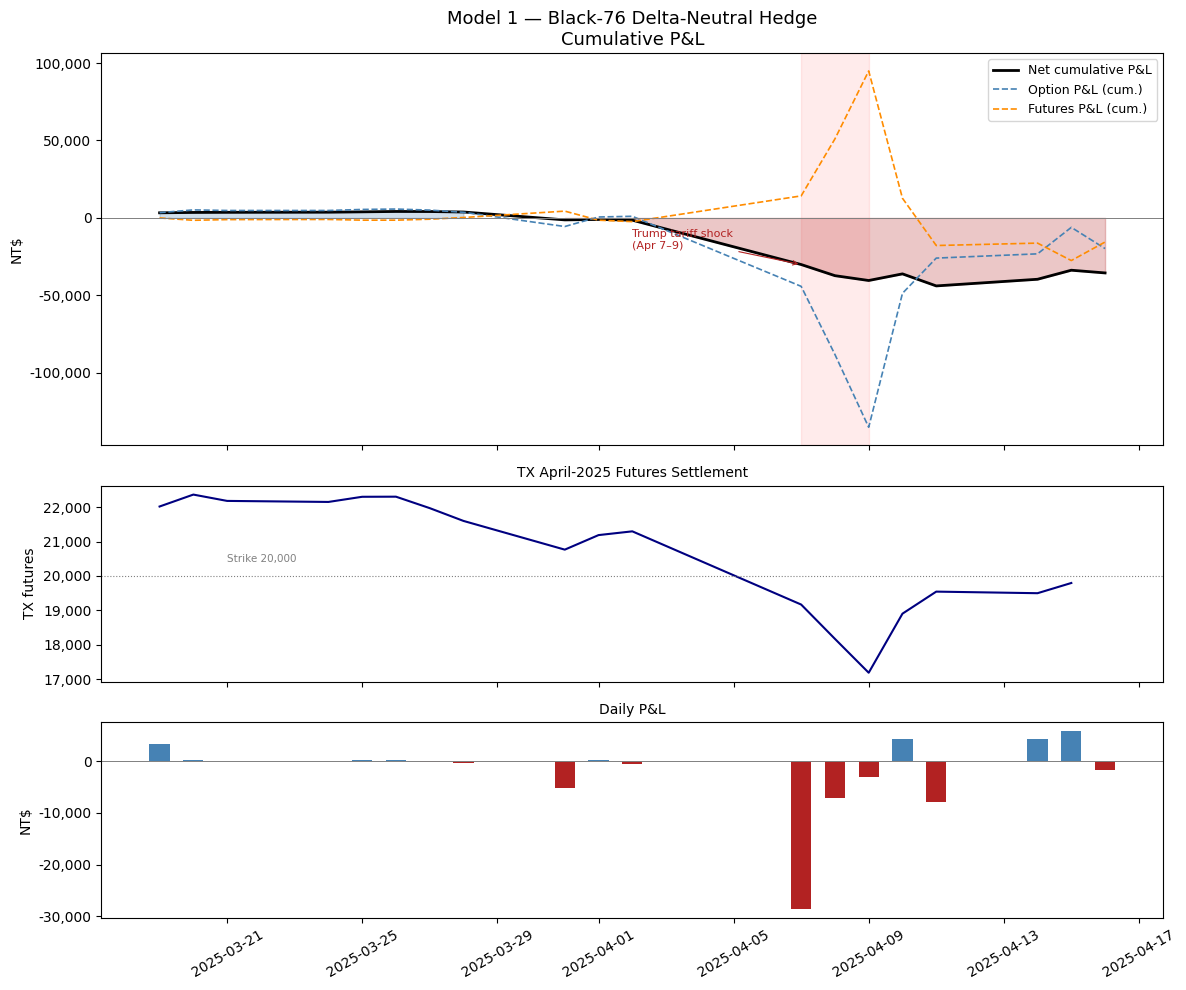

In [7]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True,
                          gridspec_kw={"height_ratios": [2, 1, 1]})

# ── Panel 1: Cumulative P&L with component breakdown ──────────────────────────
ax = axes[0]
ax.fill_between(df.index, df["cum_pnl"], 0,
                where=df["cum_pnl"] >= 0, alpha=0.25, color="steelblue", label="_nolegend_")
ax.fill_between(df.index, df["cum_pnl"], 0,
                where=df["cum_pnl"] < 0,  alpha=0.25, color="firebrick", label="_nolegend_")
ax.plot(df.index, df["cum_pnl"], color="black", linewidth=2, label="Net cumulative P&L")
ax.plot(df.index, df["option_pnl"].cumsum(),  color="steelblue", linewidth=1.2,
        linestyle="--", label="Option P&L (cum.)")
ax.plot(df.index, df["futures_pnl"].cumsum(), color="darkorange", linewidth=1.2,
        linestyle="--", label="Futures P&L (cum.)")
ax.axhline(0, color="grey", linewidth=0.7)
ax.set_ylabel("NT$")
ax.set_title("Model 1 — Black-76 Delta-Neutral Hedge\nCumulative P&L", fontsize=13)
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# Annotate the April 3–9 crash window
ax.axvspan(pd.Timestamp("2025-04-07"), pd.Timestamp("2025-04-09"),
           alpha=0.08, color="red", label="Crash window")
ax.annotate("Trump tariff shock\n(Apr 7–9)",
            xy=(pd.Timestamp("2025-04-07"), df.loc["2025-04-07", "cum_pnl"]),
            xytext=(pd.Timestamp("2025-04-02"), -20000),
            fontsize=8, color="firebrick",
            arrowprops=dict(arrowstyle="->", color="firebrick", lw=0.8))

# ── Panel 2: TX futures price ─────────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(df.index, df["F"], color="navy", linewidth=1.5)
ax2.axhline(STRIKE, color="grey", linewidth=0.8, linestyle=":")
ax2.annotate(f"Strike {STRIKE:,.0f}", xy=(df.index[2], STRIKE),
             xytext=(df.index[2], STRIKE + 400), fontsize=7.5, color="grey")
ax2.set_ylabel("TX futures")
ax2.set_title("TX April-2025 Futures Settlement", fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

# ── Panel 3: daily P&L bars ───────────────────────────────────────────────────
ax3 = axes[2]
colors = ["steelblue" if v >= 0 else "firebrick" for v in df["total_pnl"]]
ax3.bar(df.index, df["total_pnl"], color=colors, width=0.6)
ax3.axhline(0, color="grey", linewidth=0.7)
ax3.set_ylabel("NT$")
ax3.set_title("Daily P&L", fontsize=10)
ax3.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))

for ax_ in axes:
    ax_.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_cumulative_pnl.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. IV and Delta Evolution

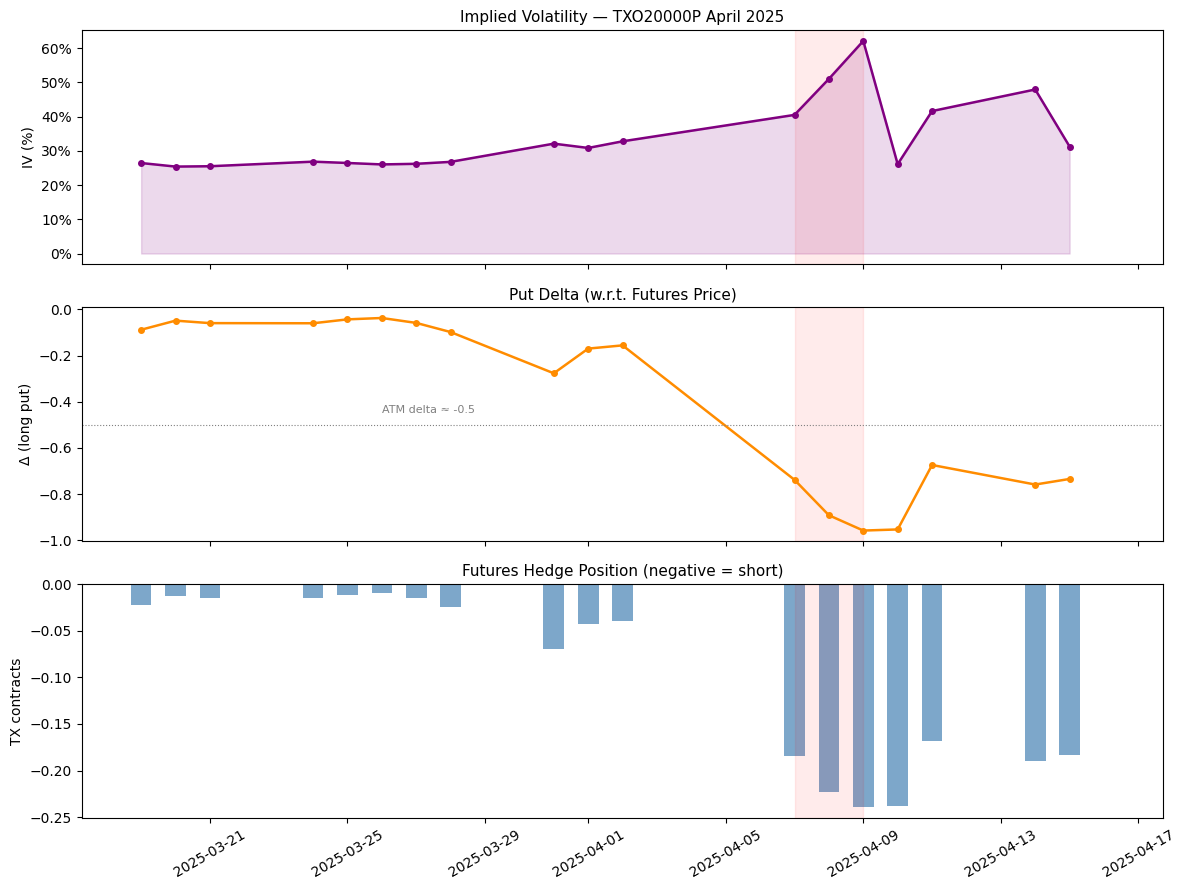

In [8]:
# Only non-expiry rows have IV
df_iv = df[df["iv"].notna()].copy()

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

# ── IV (%) ────────────────────────────────────────────────────────────────────
ax1.plot(df_iv.index, df_iv["iv_pct"], color="purple", linewidth=1.8, marker="o", ms=4)
ax1.fill_between(df_iv.index, df_iv["iv_pct"], alpha=0.15, color="purple")
ax1.set_ylabel("IV (%)")
ax1.set_title("Implied Volatility — TXO20000P April 2025", fontsize=11)
ax1.axvspan(pd.Timestamp("2025-04-07"), pd.Timestamp("2025-04-09"),
            alpha=0.08, color="red")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0f}%"))

# ── Delta (long put, negative) ────────────────────────────────────────────────
ax2.plot(df_iv.index, df_iv["delta"], color="darkorange", linewidth=1.8, marker="o", ms=4)
ax2.axhline(-0.5, color="grey", linewidth=0.8, linestyle=":")
ax2.annotate("ATM delta ≈ -0.5", xy=(df_iv.index[5], -0.5),
             xytext=(df_iv.index[5], -0.45), fontsize=8, color="grey")
ax2.set_ylabel("Δ (long put)")
ax2.set_title("Put Delta (w.r.t. Futures Price)", fontsize=11)
ax2.axvspan(pd.Timestamp("2025-04-07"), pd.Timestamp("2025-04-09"),
            alpha=0.08, color="red")

# ── Hedge position (TX contracts, negative = short) ───────────────────────────
ax3.bar(df.index, df["futures_position"], color="steelblue", width=0.6, alpha=0.7)
ax3.axhline(0, color="grey", linewidth=0.7)
ax3.set_ylabel("TX contracts")
ax3.set_title("Futures Hedge Position (negative = short)", fontsize=11)
ax3.axvspan(pd.Timestamp("2025-04-07"), pd.Timestamp("2025-04-09"),
            alpha=0.08, color="red")

for ax_ in [ax1, ax2, ax3]:
    ax_.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_iv_delta.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. P&L Attribution

Decompose the **option P&L** (excluding futures hedge and costs) into:

| Component | Formula | Sign for short put |
|-----------|---------|---------------------|
| Theta | $-\Theta_t \times 50$ | Positive (time decay benefit) |
| Gamma | $-\frac{1}{2}\Gamma_t \,(\Delta F)^2 \times 50$ | Negative (short gamma suffers large moves) |
| Vega  | $-\mathcal{V}_t \,\Delta\sigma \times 50$ | Negative when vol rises |
| Residual | Total option P&L − (Θ + Γ + V) | Jump / discrete-rehedge error |

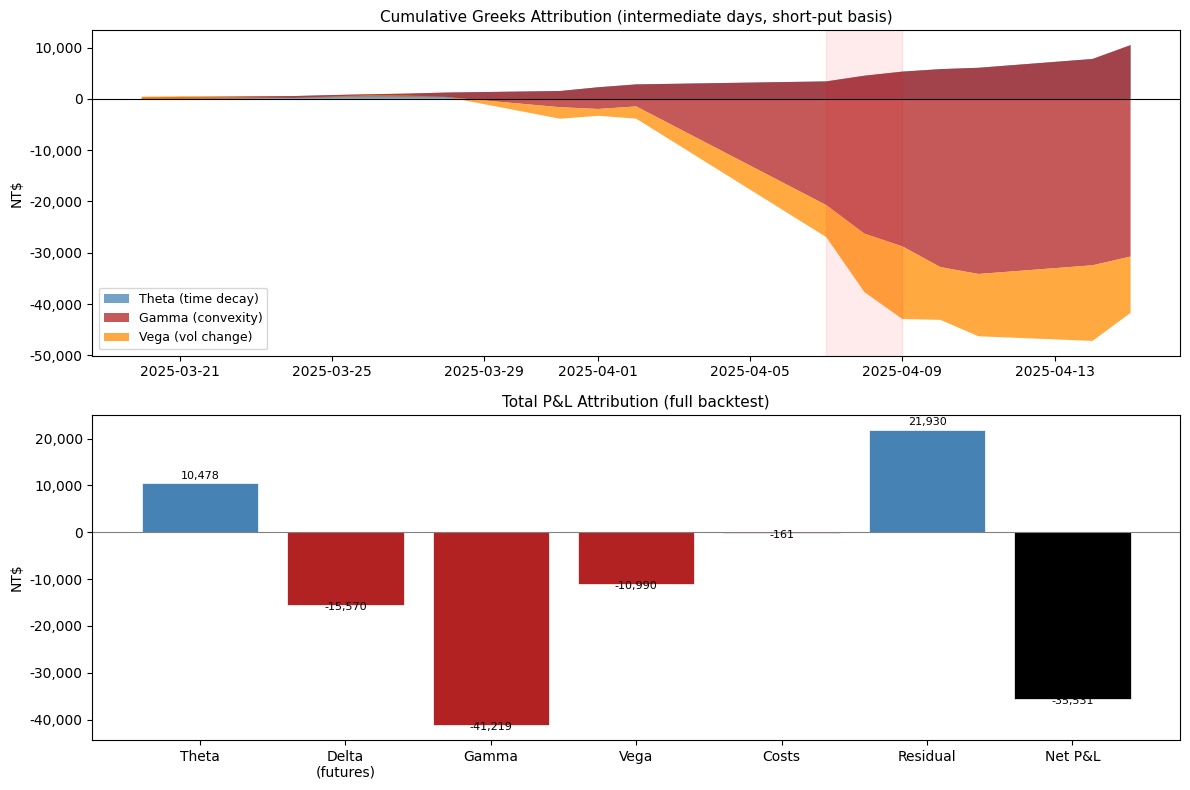

Attribution check: -35,531  (Net P&L = -35,531)  ✓


In [9]:
# Cumulative Greek attribution (intermediate days where attribution is computed)
df_mid = df[(df.index > df.index[0]) & (df.index < EXPIRY)].copy()

theta_cum  = df_mid["theta_pnl"].cumsum()
gamma_cum  = df_mid["gamma_pnl"].cumsum()
vega_cum   = df_mid["vega_pnl"].cumsum()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# ── Panel 1: stacked cumulative attribution ───────────────────────────────────
ax = axes[0]
ax.stackplot(
    df_mid.index,
    theta_cum, gamma_cum, vega_cum,
    labels=["Theta (time decay)", "Gamma (convexity)", "Vega (vol change)"],
    colors=["steelblue", "firebrick", "darkorange"],
    alpha=0.75,
)
ax.axhline(0, color="black", linewidth=0.8)
ax.set_ylabel("NT$")
ax.set_title("Cumulative Greeks Attribution (intermediate days, short-put basis)", fontsize=11)
ax.legend(fontsize=9, loc="lower left")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
ax.axvspan(pd.Timestamp("2025-04-07"), pd.Timestamp("2025-04-09"),
           alpha=0.08, color="red")

# ── Panel 2: total attribution bar chart ─────────────────────────────────────
ax2 = axes[1]
total       = df["total_pnl"].sum()
opt_total   = df["option_pnl"].sum()
fut_total   = df["futures_pnl"].sum()
cost_total  = df["cost"].sum()
theta_total = df["theta_pnl"].sum()
gamma_total = df["gamma_pnl"].sum()
vega_total  = df["vega_pnl"].sum()
resid_total = opt_total - (theta_total + gamma_total + vega_total)

labels  = ["Theta", "Delta\n(futures)", "Gamma", "Vega", "Costs", "Residual", "Net P&L"]
values  = [theta_total, fut_total, gamma_total, vega_total, cost_total, resid_total, total]
colors2 = ["steelblue" if v >= 0 else "firebrick" for v in values]
colors2[-1] = "black"

bars = ax2.bar(labels, values, color=colors2, edgecolor="white", linewidth=0.5)
ax2.axhline(0, color="grey", linewidth=0.8)
ax2.set_ylabel("NT$")
ax2.set_title("Total P&L Attribution (full backtest)", fontsize=11)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
for bar, val in zip(bars, values):
    ypos = val + 500 if val >= 0 else val - 1500
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f"{val:,.0f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig(ROOT / "notebooks" / "fig_attribution.png", dpi=150, bbox_inches="tight")
plt.show()

check = theta_total + fut_total + gamma_total + vega_total + cost_total + resid_total
print(f"Attribution check: {check:,.0f}  (Net P&L = {total:,.0f})  {'✓' if abs(check-total)<1 else '✗'}")

## 9. Summary & Key Takeaways

In [10]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary_rows = [
    ("Option P&L (premium + MTM)",     opt_total),
    ("  of which: premium received",    premium_received),
    ("  of which: MTM changes",         opt_total - premium_received),
    ("Futures hedge P&L",               fut_total),
    ("Transaction costs",               cost_total),
    ("NET P&L",                         total),
]
attr_rows = [
    ("  Theta  (time decay)",           theta_total),
    ("  Delta  (futures hedge)",        fut_total),
    ("  Gamma  (convexity cost)",       gamma_total),
    ("  Vega   (vol mark-to-mkt)",      vega_total),
    ("  Costs",                         cost_total),
    ("  Residual (model/jump error)",   resid_total),
    ("  ─── Check",                     check),
]

print("=" * 52)
print(f"  Model 1: Black-76 Delta-Neutral Backtest")
print(f"  Short 1× TXO20000P5, hedge via TX futures")
print(f"  Period: 2025-03-19 → 2025-04-16  (19 days)")
print("=" * 52)
for label, val in summary_rows:
    sep = "─" * 40 if label == "NET P&L" else ""
    if sep:
        print(f"  {sep}")
    print(f"  {label:<38} NT$ {val:>10,.0f}")
print()
print("  P&L Attribution:")
for label, val in attr_rows:
    print(f"  {label:<38} NT$ {val:>10,.0f}")
print("=" * 52)
print()
print("  ⚠  Final settlement is APPROXIMATE.")
print(f"     Used TAIEX close 2025-04-16 = {FINAL_SETTLE:,.0f}")
print(f"     Intrinsic payoff = NT${max(0,STRIKE-FINAL_SETTLE)*OPT_MULT:,.0f}")
print(f"     Actual TAIFEX SOQ may differ (see CLAUDE.md §Data Notes).")

  Model 1: Black-76 Delta-Neutral Backtest
  Short 1× TXO20000P5, hedge via TX futures
  Period: 2025-03-19 → 2025-04-16  (19 days)
  Option P&L (premium + MTM)             NT$    -19,800
    of which: premium received           NT$      3,400
    of which: MTM changes                NT$    -23,200
  Futures hedge P&L                      NT$    -15,570
  Transaction costs                      NT$       -161
  ────────────────────────────────────────
  NET P&L                                NT$    -35,531

  P&L Attribution:
    Theta  (time decay)                  NT$     10,478
    Delta  (futures hedge)               NT$    -15,570
    Gamma  (convexity cost)              NT$    -41,219
    Vega   (vol mark-to-mkt)             NT$    -10,990
    Costs                                NT$       -161
    Residual (model/jump error)          NT$     21,930
    ─── Check                            NT$    -35,531

  ⚠  Final settlement is APPROXIMATE.
     Used TAIEX close 2025-04-16 = 19,

In [11]:
# ── Key observations ──────────────────────────────────────────────────────────
worst_day   = df["total_pnl"].idxmin()
best_day    = df["total_pnl"].idxmax()
max_iv      = df_iv["iv_pct"].max()
max_iv_date = df_iv["iv_pct"].idxmax()
peak_pnl    = df["cum_pnl"].max()
peak_date   = df["cum_pnl"].idxmax()
max_hedge   = df["futures_position"].abs().max()
max_hedge_d = df["futures_position"].abs().idxmax()

print("Key observations:")
print(f"  Worst day  : {worst_day.date()}  NT$ {df.loc[worst_day,'total_pnl']:,.0f}")
print(f"  Best day   : {best_day.date()}   NT$ {df.loc[best_day,'total_pnl']:,.0f}")
print(f"  Peak P&L   : NT$ {peak_pnl:,.0f}  on {peak_date.date()}")
print(f"  Max IV     : {max_iv:.1f}%  on {max_iv_date.date()}")
print(f"  Max hedge  : {max_hedge:.4f} TX contracts  on {max_hedge_d.date()}")
print()
print("Interpretation:")
print("  The Trump tariff shock (Apr 3–9) caused a ~22% index drop.")
print("  The delta hedge was far too small (only 0.04 TX on Apr 2) to offset")
print("  the gamma P&L loss of NT$41,219 as the option went deep ITM.")
print("  Theta earned (NT$10,478) was overwhelmed by gamma + vega costs.")
print("  The futures hedge itself also net lost (NT$-15,570) because the")
print("  large short position built up during the crash was whipsawed on")
print("  the partial recovery (Apr 10: +1,718 pts).")

Key observations:
  Worst day  : 2025-04-07  NT$ -28,643
  Best day   : 2025-04-15   NT$ 5,842
  Peak P&L   : NT$ 4,167  on 2025-03-26
  Max IV     : 62.1%  on 2025-04-09
  Max hedge  : 0.2393 TX contracts  on 2025-04-09

Interpretation:
  The Trump tariff shock (Apr 3–9) caused a ~22% index drop.
  The delta hedge was far too small (only 0.04 TX on Apr 2) to offset
  the gamma P&L loss of NT$41,219 as the option went deep ITM.
  Theta earned (NT$10,478) was overwhelmed by gamma + vega costs.
  The futures hedge itself also net lost (NT$-15,570) because the
  large short position built up during the crash was whipsawed on
  the partial recovery (Apr 10: +1,718 pts).


In [12]:
# Save results to processed/
PROCESSED.mkdir(parents=True, exist_ok=True)
df.to_csv(PROCESSED / "model1_results.csv")
print(f"Results saved to {PROCESSED / 'model1_results.csv'}")

Results saved to /Users/chiushihchan/Local/kgi interview/data/processed/model1_results.csv
